In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =========================================================
# ⚡ PM2.5 Classification (5 Classes) using Parallel Linear SVM (SGDClassifier) + Borderline-SMOTE (Train only)
# =========================================================
# === Block 1: Import Libraries ===
!pip install tqdm -q

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.preprocessing import label_binarize
from tqdm import tqdm
import os, warnings

warnings.filterwarnings('ignore')


In [3]:
# === Block 2: Optimize Resource Usage ===
os.environ['OMP_NUM_THREADS'] = str(os.cpu_count())
print(f"💻 Using CPU Threads: {os.cpu_count()}")
!free -h && nproc

💻 Using CPU Threads: 2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.3Gi       7.9Gi       1.0Mi       3.5Gi        11Gi
Swap:             0B          0B          0B
2


In [4]:
# === Block 3: Load Dataset ===
train_path = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/train_split.csv"
test_path  = "/content/drive/MyDrive/Senior_Project/dataset/PM2.5 dataset/test_split.csv"

df_train = pd.read_csv(train_path)
df_test  = pd.read_csv(test_path)
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")

Train shape: (329623, 13), Test shape: (82406, 13)


In [5]:
# === Block 4: Separate Features and Target ===
TARGET = 'PM2.5_level'
X_train = df_train.drop(columns=[TARGET])
y_train = df_train[TARGET]
X_test  = df_test.drop(columns=[TARGET])
y_test  = df_test[TARGET]

In [6]:
# === Block 5: Apply Borderline-SMOTE before 10-Fold ===
print("Before SMOTE:")
print(y_train.value_counts())

bsmote = BorderlineSMOTE(kind='borderline-1', random_state=42)
X_resampled, y_resampled = bsmote.fit_resample(X_train, y_train)

print("\nAfter Borderline-SMOTE:")
print(pd.Series(y_resampled).value_counts())

Before SMOTE:
PM2.5_level
5    128801
4     73062
1     64314
2     33504
3     29942
Name: count, dtype: int64

After Borderline-SMOTE:
PM2.5_level
5    128801
3    128801
2    128801
4    128801
1    128801
Name: count, dtype: int64


In [7]:
# === Block 6: 10-Fold Cross Validation ===
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

acc_scores, prec_scores, rec_scores, f1_scores, auc_scores = [], [], [], [], []
model = SGDClassifier(loss='hinge', random_state=42, max_iter=5000, n_jobs=-1)

for fold, (train_idx, val_idx) in enumerate(tqdm(skf.split(X_resampled, y_resampled), total=10), 1):
    X_tr, X_val = X_resampled.iloc[train_idx], X_resampled.iloc[val_idx]
    y_tr, y_val = y_resampled.iloc[train_idx], y_resampled.iloc[val_idx]

    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_val)
    y_val_score = model.decision_function(X_val)

    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_val, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_val, y_pred, average='weighted')
    y_val_bin = label_binarize(y_val, classes=sorted(y_resampled.unique()))
    auc_val = roc_auc_score(y_val_bin, y_val_score, average='macro', multi_class='ovr')

    acc_scores.append(acc)
    prec_scores.append(prec)
    rec_scores.append(rec)
    f1_scores.append(f1)
    auc_scores.append(auc_val)

    print(f"Fold {fold}: Accuracy={acc:.3f}, Precision={prec:.3f}, Recall={rec:.3f}, F1={f1:.3f}, AUC={auc_val:.3f}")

 10%|█         | 1/10 [00:04<00:36,  4.01s/it]

Fold 1: Accuracy=0.477, Precision=0.391, Recall=0.477, F1=0.358, AUC=0.766


 20%|██        | 2/10 [00:08<00:33,  4.15s/it]

Fold 2: Accuracy=0.462, Precision=0.363, Recall=0.462, F1=0.381, AUC=0.759


 30%|███       | 3/10 [00:13<00:31,  4.53s/it]

...

Fold 8: Accuracy=0.443, Precision=0.369, Recall=0.443, F1=0.349, AUC=0.765


 90%|█████████ | 9/10 [00:40<00:04,  4.80s/it]

Fold 9: Accuracy=0.478, Precision=0.292, Recall=0.478, F1=0.361, AUC=0.762


100%|██████████| 10/10 [00:44<00:00,  4.47s/it]

Fold 10: Accuracy=0.496, Precision=0.459, Recall=0.496, F1=0.401, AUC=0.754


In [8]:
# === Block 7: Display CV Summary (with Mean ± SD) ===
import os

cv_results = pd.DataFrame({
    'Fold': list(range(1, len(acc_scores)+1)),
    'Accuracy': acc_scores,
    'Precision': prec_scores,
    'Recall': rec_scores,
    'F1': f1_scores,
    'AUC_ROC': auc_scores
})

print("\n=== 10-Fold Cross Validation Results ===")
print(cv_results)

# === คำนวณ Mean ± SD ===
acc_mean, acc_sd = np.mean(acc_scores), np.std(acc_scores)
prec_mean, prec_sd = np.mean(prec_scores), np.std(prec_scores)
rec_mean, rec_sd = np.mean(rec_scores), np.std(rec_scores)
f1_mean, f1_sd = np.mean(f1_scores), np.std(f1_scores)
auc_mean, auc_sd = np.mean(auc_scores), np.std(auc_scores)

# === แสดงผลรวม (Mean ± SD) ===
print("\n📊 Cross-validation (10 folds) Metrics (Mean ± SD):")
print(f"Accuracy : {acc_mean:.3f} ± {acc_sd:.3f}")
print(f"Precision: {prec_mean:.3f} ± {prec_sd:.3f}")
print(f"Recall   : {rec_mean:.3f} ± {rec_sd:.3f}")
print(f"F1-score : {f1_mean:.3f} ± {f1_sd:.3f}")
print(f"AUC-ROC  : {auc_mean:.3f} ± {auc_sd:.3f}")




=== 10-Fold Cross Validation Results ===
   Fold  Accuracy  Precision    Recall        F1   AUC_ROC
0     1  0.476716   0.391148  0.476716  0.358373  0.765862
1     2  0.462074   0.363278  0.462074  0.381396  0.758736
2     3  0.507523   0.395496  0.507523  0.394097  0.762719
3     4  0.476576   0.428579  0.476576  0.413437  0.762031
4     5  0.502818   0.355760  0.502818  0.378940  0.750474
5     6  0.491646   0.460213  0.491646  0.406826  0.757885
6     7  0.448711   0.356880  0.448711  0.356866  0.752245
7     8  0.443370   0.369462  0.443370  0.348802  0.765497
8     9  0.478494   0.291732  0.478494  0.361138  0.761830
9    10  0.496149   0.458790  0.496149  0.401188  0.753824

📊 Cross-validation (10 folds) Metrics (Mean ± SD):
Accuracy : 0.478 ± 0.021
Precision: 0.387 ± 0.049
Recall   : 0.478 ± 0.021
F1-score : 0.380 ± 0.022
AUC-ROC  : 0.759 ± 0.005


In [9]:
# 💾 (Optional) บันทึกค่า Mean ± SD ลงไฟล์ CSV
cv_summary = pd.DataFrame([{
    "Accuracy_mean": acc_mean, "Accuracy_sd": acc_sd,
    "Precision_mean": prec_mean, "Precision_sd": prec_sd,
    "Recall_mean": rec_mean, "Recall_sd": rec_sd,
    "F1_mean": f1_mean, "F1_sd": f1_sd,
    "AUC_mean": auc_mean, "AUC_sd": auc_sd
}])

base_path = '/content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/'
summary_path = base_path + "SVM_CV_MeanSD.csv"

# ✅ สร้างโฟลเดอร์อัตโนมัติ (กัน error)
os.makedirs(base_path, exist_ok=True)

cv_summary.to_csv(summary_path, index=False)
print(f"\n💾 Mean + SD summary saved to {summary_path}")


💾 Mean + SD summary saved to /content/drive/MyDrive/Senior_Project/roc/SVM_Roc/all/MeanSD/SVM_CV_MeanSD.csv


In [10]:
# === Block 8: Evaluate on Test Set ===
model.fit(X_resampled, y_resampled)
y_pred_test = model.predict(X_test)
y_test_score = model.decision_function(X_test)

classes = sorted(y_resampled.unique())
y_test_bin = label_binarize(y_test, classes=classes)

acc_test = accuracy_score(y_test, y_pred_test)
prec_test = precision_score(y_test, y_pred_test, average='weighted', zero_division=0)
rec_test = recall_score(y_test, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test, y_pred_test, average='weighted', zero_division=0)
test_auc = roc_auc_score(y_test_bin, y_test_score, average='macro', multi_class='ovr')

print("\n📈 Test Set Metrics:")
print(f"Accuracy: {acc_test:.3f}, Precision: {prec_test:.3f}, Recall: {rec_test:.3f}, F1: {f1_test:.3f}, AUC: {test_auc:.3f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_test))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_test))



📈 Test Set Metrics:
Accuracy: 0.639, Precision: 0.582, Recall: 0.639, F1: 0.575, AUC: 0.783

Classification Report:
               precision    recall  f1-score   support

           1       0.64      0.95      0.76     16078
           2       0.23      0.02      0.04      8376
           3       0.26      0.34      0.29      7486
           4       0.51      0.19      0.28     18265
           5       0.76      0.97      0.85     32201

    accuracy                           0.64     82406
   macro avg       0.48      0.49      0.45     82406
weighted avg       0.58      0.64      0.58     82406

Confusion Matrix:
 [[15208    47   437   277   109]
 [ 5523   196  1462  1018   177]
 [ 2136   253  2578  1775   744]
 [  810   344  4978  3510  8623]
 [   47    27   615   360 31152]]


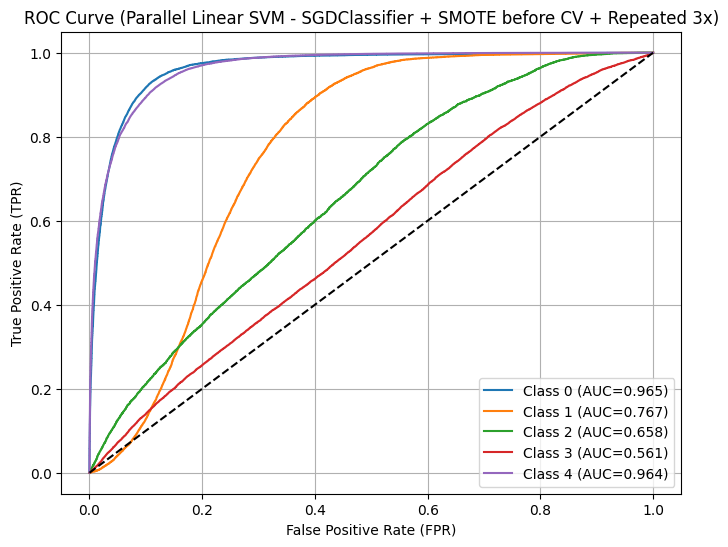

In [ ]:
# === Block 9: ROC Curve ===
n_classes = len(classes)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_test_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8,6))
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC={roc_auc[i]:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve (Parallel Linear SVM - SGDClassifier + SMOTE before CV + Repeated 3x)')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# === Block 10: Save Model, AUC CSV, and ROC Data ===
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Senior_Project/'
joblib.dump(model, base_path + 'svm_sgd_borderline.pkl')
print(f"💾 Model saved as {base_path}svm_sgd_borderline.pkl")

output_auc = pd.DataFrame({
    'Fold': list(range(1, len(acc_scores)+1)) + ['Test Set'],
    'AUC_ROC': auc_scores + [test_auc]
})
output_auc.to_csv(base_path + 'svm_sgd_borderline_scores.csv', index=False)
print(f"💾 AUC results saved as {base_path}svm_sgd_borderline_scores.csv")

all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(n_classes):
    mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
mean_tpr /= n_classes
macro_auc = auc(all_fpr, mean_tpr)

roc_df = pd.DataFrame({'fpr': all_fpr, 'tpr': mean_tpr})
roc_df.to_csv(base_path + 'svm_sgd_borderline_roc_data.csv', index=False)
print(f"💾 ROC data saved as {base_path}svm_sgd_borderline_roc_data.csv")
print(f"Macro AUC = {macro_auc:.4f}")
print(roc_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
💾 Model saved as /content/drive/MyDrive/Senior_Project/svm_sgd_borderline.pkl
💾 AUC results saved as /content/drive/MyDrive/Senior_Project/svm_sgd_borderline_scores.csv
💾 ROC data saved as /content/drive/MyDrive/Senior_Project/svm_sgd_borderline_roc_data.csv
Macro AUC = 0.7829
        fpr       tpr
0  0.000000  0.002975
1  0.000013  0.002975
2  0.000015  0.003983
3  0.000016  0.003994
4  0.000020  0.004087
